### Load Dataset & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('air-quality-1.csv')

display(df.head())
display(df.info())

,indicator_data_id,indicator_id,name,Measure,geo_type_name,geo_entity_id,geo_entity_name,year_description,data_valuemessage
0,130728,646,Air Toxics Concentrations- Average Benzene Con...,Average Concentration,Borough,1,Bronx,2005,2.8
1,130729,646,Air Toxics Concentrations- Average Benzene Con...,Average Concentration,Borough,2,Brooklyn,2005,2.8
2,130730,646,Air Toxics Concentrations- Average Benzene Con...,Average Concentration,Borough,3,Manhattan,2005,4.7
3,130731,646,Air Toxics Concentrations- Average Benzene Con...,Average Concentration,Borough,4,Queens,2005,1.9
4,130732,646,Air Toxics Concentrations- Average Benzene Con...,Average Concentration,Borough,5,Staten Island,2005,1.6


<class 'pandas.DataFrame'>
RangeIndex: 2769 entries, 0 to 2768
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   indicator_data_id  2769 non-null   int64  
 1   indicator_id       2769 non-null   int64  
 2   name               2769 non-null   str    
 3   Measure            2769 non-null   str    
 4   geo_type_name      2769 non-null   str    
 5   geo_entity_id      2769 non-null   int64  
 6   geo_entity_name    2769 non-null   str    
 7   year_description   2769 non-null   str    
 8   data_valuemessage  2736 non-null   float64
dtypes: float64(1), int64(3), str(5)
memory usage: 194.8 KB


None

## 1. Data Cleaning & Preparation

### Column Renaming & Type Checking

In [2]:
df = df.rename(columns={'data_valuemessage': 'data_value'})
df['data_value'] = pd.to_numeric(df['data_value'], errors='coerce')

print(df.dtypes)

indicator_data_id      int64
indicator_id           int64
name                     str
Measure                  str
geo_type_name            str
geo_entity_id          int64
geo_entity_name          str
year_description         str
data_value           float64
dtype: object


### Remove Misaligned Records

In [3]:
# A few CD-level Traffic Density rows have shifted fields (neighborhood text
# ended up in year_description instead of a year), so drop those.
df = df[df['year_description'].str.contains(r'\d')]
print(f"Dataset shape: {df.shape}")

Dataset shape: (2616, 9)


### Check Missing Data

In [4]:
print("Missing values per column:")
print(df[['geo_entity_name', 'Measure', 'data_value']].isnull().sum())

df = df.dropna(subset=['geo_entity_name', 'Measure', 'data_value'])
print(f"Dataset shape after dropping missing values: {df.shape}")

Missing values per column:
geo_entity_name    0
Measure            0
data_value         0
dtype: int64
Dataset shape after dropping missing values: (2616, 9)


### Remove Duplicates

In [5]:
duplicate_count = df.duplicated(subset=['indicator_data_id']).sum()
print(f"Number of duplicate rows found: {duplicate_count}")

df = df.drop_duplicates(subset=['indicator_data_id'])
print(f"Dataset shape after removing duplicates: {df.shape}")

Number of duplicate rows found: 960
Dataset shape after removing duplicates: (1656, 9)


## 2. Summary Statistics & Correlation Analysis

### Summary Statistics

In [6]:
display(df.groupby('name')['data_value'].describe())

print("\nMode values:")
print(df.groupby('name')['data_value'].agg(lambda x: x.mode().iloc[0]))

,count,mean,std,min,25%,50%,75%,max
name,,,,,,,,
Air Toxics Concentrations- Average Benzene Concentrations,48.0,2.910417,1.166599,1.1,1.975,2.75,3.700,6.3
Air Toxics Concentrations- Average Formaldehyde Concentrations,48.0,3.195833,0.742898,2.0,2.650,3.20,3.600,5.3
Boiler Emissions- Total NOx Emissions,48.0,56.300000,70.814099,2.0,14.650,28.60,64.625,284.7
Boiler Emissions- Total PM2.5 Emissions,48.0,1.660417,2.859827,0.0,0.100,0.30,2.000,11.4
Boiler Emissions- Total SO2 Emissions,48.0,14.231250,24.974312,0.0,0.475,2.30,16.000,99.7
Neighborhood Air Quality Concentrations- Elemental Carbon (EC),48.0,1.193750,0.269283,0.7,1.000,1.15,1.400,1.8
Neighborhood Air Quality Concentrations- Fine Particulate Matter (PM2.5),48.0,10.625000,1.328813,8.9,9.575,10.45,11.175,14.9
Neighborhood Air Quality Concentrations- Nitric Oxide (NO),48.0,26.931250,9.493002,13.5,20.575,25.15,29.650,53.6
Neighborhood Air Quality Concentrations- Nitrogen Dioxide (NO2),48.0,24.670833,5.354336,15.7,21.525,24.10,26.425,41.8



Mode values:
name
Air Toxics Concentrations- Average Benzene Concentrations                         2.8
Air Toxics Concentrations- Average Formaldehyde Concentrations                    3.2
Boiler Emissions- Total NOx Emissions                                             2.0
Boiler Emissions- Total PM2.5 Emissions                                           0.0
Boiler Emissions- Total SO2 Emissions                                             0.0
Neighborhood Air Quality Concentrations- Elemental Carbon (EC)                    1.0
Neighborhood Air Quality Concentrations- Fine Particulate Matter (PM2.5)          9.7
Neighborhood Air Quality Concentrations- Nitric Oxide (NO)                       19.1
Neighborhood Air Quality Concentrations- Nitrogen Dioxide (NO2)                  20.9
Neighborhood Air Quality Concentrations- Ozone (O3)                              27.1
Neighborhood Air Quality Concentrations: Sulfur Dioxide (SO2)                     3.3
O3-Attributable Asthma ED Visits   

## 3. Pollutant Concentration Breakdown

name
Air Toxics Concentrations- Average Benzene Concentrations          2.910417
Air Toxics Concentrations- Average Formaldehyde Concentrations     3.195833
Boiler Emissions- Total NOx Emissions                             56.300000
Name: data_value, dtype: float64

/tmp/ipykernel_536/3297674024.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pollutant_avg.values, y=pollutant_avg.index, palette='mako')


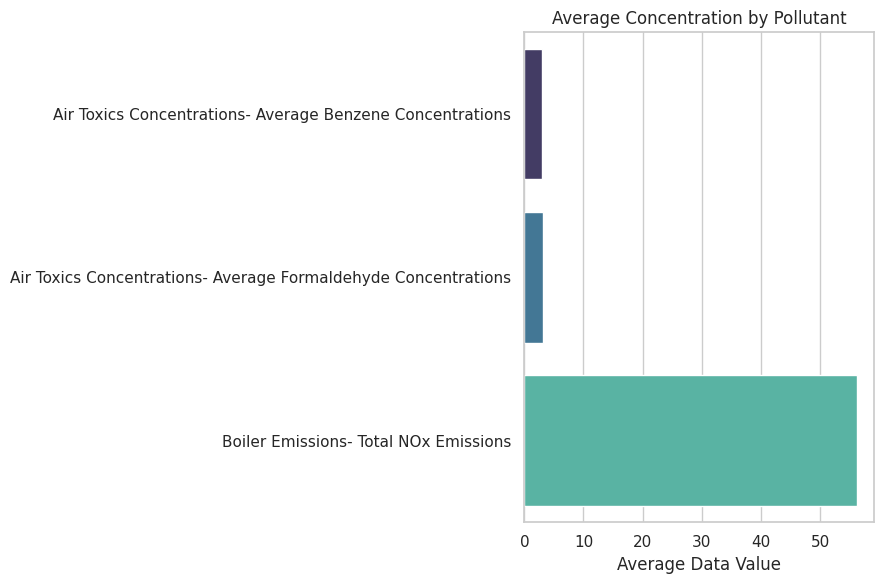

In [8]:
key_pollutants = [
    'Air Toxics Concentrations- Average Benzene Concentrations',
    'Air Toxics Concentrations- Average Formaldehyde Concentrations',
    'Boiler Emissions- Total NOx Emissions'
]

pollutant_avg = df[df['name'].isin(key_pollutants)].groupby('name')['data_value'].mean()
display(pollutant_avg)

plt.figure(figsize=(9, 6))
sns.barplot(x=pollutant_avg.values, y=pollutant_avg.index, palette='mako')
plt.title('Average Concentration by Pollutant')
plt.xlabel('Average Data Value')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 4. Borough-Level Comparison

geo_entity_name
Bronx            46.376471
Manhattan        41.344118
Brooklyn         30.023529
Queens           22.832353
Staten Island    20.482353
Name: data_value, dtype: float64

/tmp/ipykernel_536/1249727489.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=borough_summary.values, y=borough_summary.index, palette='viridis')


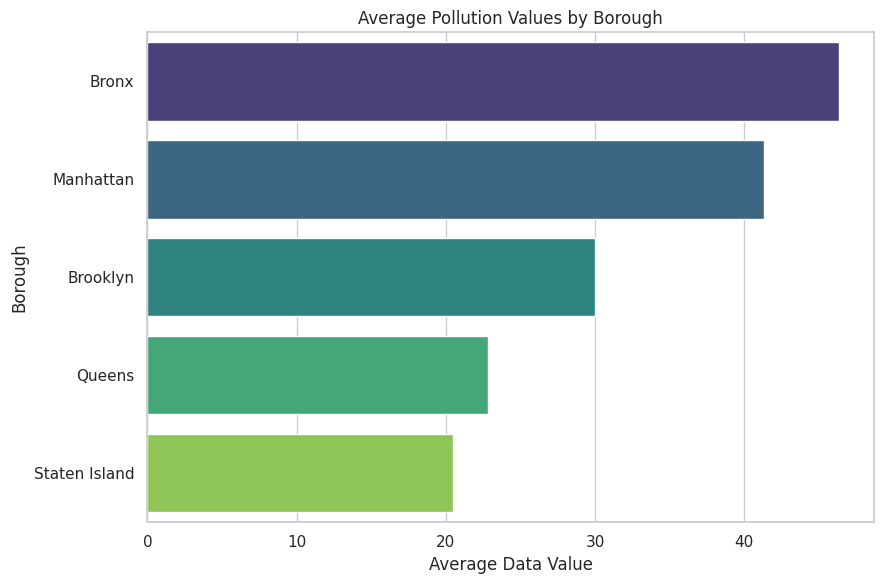

In [9]:
borough_df = df[df['geo_type_name'] == 'Borough']

borough_summary = borough_df.groupby('geo_entity_name')['data_value'].mean().sort_values(ascending=False)
display(borough_summary)

plt.figure(figsize=(9, 6))
sns.barplot(x=borough_summary.values, y=borough_summary.index, palette='viridis')
plt.title('Average Pollution Values by Borough')
plt.xlabel('Average Data Value')
plt.ylabel('Borough')
plt.tight_layout()
plt.show()

## 5. Temporal Trends Analysis

year_description
2005                         3.066667
Annual Average 2009-2010    10.642857
Name: data_value, dtype: float64

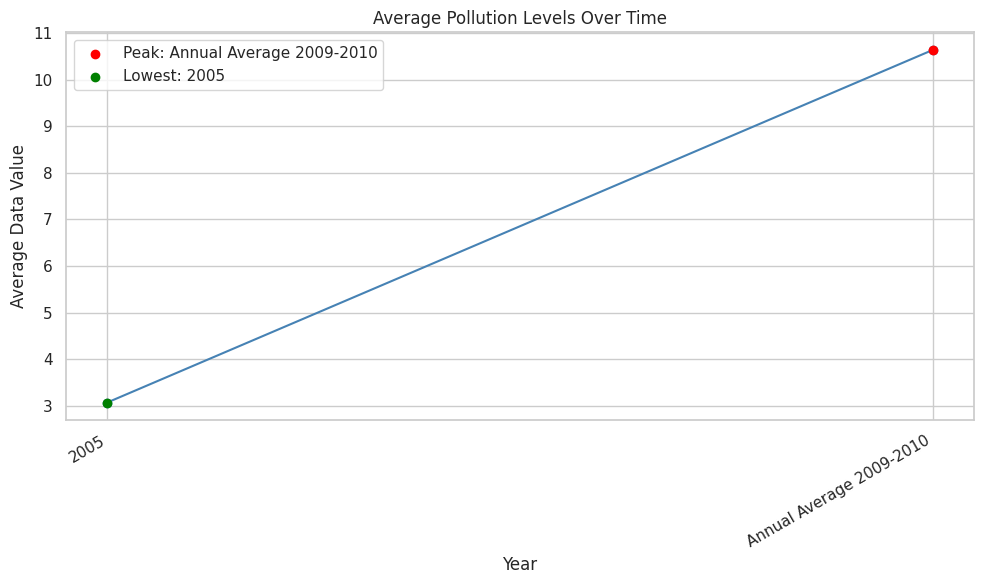

In [10]:
neighborhood_air = df[
    (df['geo_type_name'] == 'UHF42') &
    (df['name'].str.contains('Fine Particulate Matter|Air Toxics'))
]

yearly_trend = neighborhood_air.groupby('year_description')['data_value'].mean()
display(yearly_trend)

plt.figure(figsize=(10, 6))
plt.plot(yearly_trend.index, yearly_trend.values, marker='o', color='steelblue')

peak = yearly_trend.idxmax()
low = yearly_trend.idxmin()
plt.scatter(peak, yearly_trend[peak], color='red', zorder=5, label=f'Peak: {peak}')
plt.scatter(low, yearly_trend[low], color='green', zorder=5, label=f'Lowest: {low}')

plt.title('Average Pollution Levels Over Time')
plt.xlabel('Year')
plt.ylabel('Average Data Value')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()